# 3D Nasal Sinus Segmentation using SwinUNETR
**Platform:** Kaggle (GPU)

This notebook trains a SwinUNETR model on CT volumes for multi-class nasal sinus segmentation.

**Dataset:** 130 NRRD volumes with 6 classes (1 background + 5 anatomical structures)

**Key Design Choices:**
- AMP (Automatic Mixed Precision) for GPU memory efficiency
- AdamW optimizer with ReduceLROnPlateau scheduler
- DiceCE loss (combined Dice + CrossEntropy)
- Sliding window inference for validation/test
- 70/10/20 train/val/test split
- Background included in model output but excluded from metric evaluation

## Cell 1 — Install Dependencies
Install MONAI and other required packages that are not pre-installed on Kaggle.

In [1]:
# Install required packages for Kaggle environment
# monai[all] includes ITK readers, NrrdReader, etc.
# pynrrd: for raw NRRD reading in the class-balance analysis cell
# fvcore: for model complexity (FLOPs/MACs) analysis
!pip install -q "monai[all]" pynrrd fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## Cell 2 — Hardware Check
Verify that Kaggle has allocated a GPU and report the device.

In [2]:
import torch, sys, os

print(f"Python : {sys.version.split(' ')[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props    = torch.cuda.get_device_properties(0)
    mem_gb   = props.total_memory / 1e9
    print(f"GPU    : {gpu_name}")
    print(f"VRAM   : {mem_gb:.1f} GB")
else:
    print("⚠️ No GPU detected — training will be extremely slow.")

Python : 3.12.12
PyTorch: 2.10.0+cu128
CUDA   : True
GPU    : Tesla T4
VRAM   : 15.6 GB


## Cell 3 — Imports

In [3]:
import glob, json, time, random, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nrrd  # for raw NRRD reading in class-balance cell

import torch
from torch.amp import GradScaler, autocast
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from fvcore.nn import FlopCountAnalysis, parameter_count

import monai
from monai.config import print_config
from monai.data import CacheDataset, DataLoader, decollate_batch, list_data_collate
from monai.inferers import sliding_window_inference
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU, HausdorffDistanceMetric, ConfusionMatrixMetric
from monai.networks.nets import SwinUNETR
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, SpatialPadd,
    RandCropByPosNegLabeld, RandFlipd, RandRotate90d,
    RandGaussianNoised, RandShiftIntensityd, RandScaleIntensityd,
    EnsureTyped, AsDiscrete,
)
from monai.utils import set_determinism

print_config()

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-16 07:50:41.567919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776325841.961301      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776325842.065490      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776325843.029398      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776325843.029453      23 computation_placer.cc:1

MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.5
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: 2.2.0
psutil version: 5.9.5
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: 3.11.1
pynrrd version: 1.1.3
clearml version: 2.1.6rc0

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



## Cell 4 — Configuration

**Kaggle-specific changes from the local version:**
- All paths point to `/kaggle/input/nasalseg/` (read-only dataset) and `/kaggle/working/` (writable output).
- `num_workers` raised to 4 (Kaggle VMs have enough CPU cores).
- `cache_rate` lowered from 1.0 → 0.5 to avoid OOM on Kaggle's ~13 GB RAM.
- `use_checkpoint` remains True for memory-safe gradient checkpointing.
- `matplotlib` backend left as default (inline) instead of 'Agg' so plots render in Kaggle notebooks.

In [4]:
CFG = {
    
    "dataset_root":
"/kaggle/input/datasets/alaazaiter/nasalseg/NasalSeg",
    "images_dir":
"/kaggle/input/datasets/alaazaiter/nasalseg/NasalSeg/images",
    "labels_dir":
"/kaggle/input/datasets/alaazaiter/nasalseg/NasalSeg/labels",
    "output_dir": "/kaggle/working/runs/swinunetr_nasalseg_run1",
    # ---- Dataset ----
    "num_classes": 6, 
    "in_channels": 1,
    "seed": 42,
    # 5 foreground + 1 background (class 0)
    # ---- Model (SwinUNETR) ----
    "feature_size": 48,
    "norm_name": "instance",
    "drop_rate": 0.0, 
    "attn_drop_rate": 0.0,   
    "dropout_path_rate": 0.0,
    "use_checkpoint": True,

    # ---- Training / Optimisation ----
    "max_epochs":    50,
    "batch_size":     2,
    "val_batch_size": 1,
    "test_batch_size":1,
    "num_workers":    4,         # Kaggle has enough CPU cores
    "optimizer":     "AdamW",
    "learning_rate":  0.001,
    "weight_decay":   1e-5,
    "use_amp":        True,
    "grad_clip":      1.0,

    # ---- Preprocessing / Inference ----
    "roi_size":       (96, 96, 32),
    "sw_batch_size":   2,
    "infer_overlap":   0.5,
    "target_spacing": (1.0, 1.0, 1.5),
    "hu_min":         -400,
    "hu_max":          1000,
    "num_samples":     1,        # patches per training volume

    # ---- Caching ----
    # Lowered from 1.0 to 0.5 to avoid Kaggle RAM OOM.
    # Kaggle VMs typically have ~13 GB RAM; caching all 130 volumes
    # at full rate risks exceeding that.
    "cache_rate": 0.5,
}

os.makedirs(CFG["output_dir"], exist_ok=True)
CFG["device"] = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Determinism ----
set_determinism(seed=CFG["seed"])
random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG["seed"])

# ---- Class names ----
CLASS_NAMES = {
    0: "Background",
    1: "Right Maxillary Sinus",
    2: "Left Maxillary Sinus",
    3: "Right Nasal Cavity",
    4: "Left Nasal Cavity",
    5: "Nasopharynx",
}

print(f"✅ Setup complete.  Output → {CFG['output_dir']}")

✅ Setup complete.  Output → /kaggle/working/runs/swinunetr_nasalseg_run1


In [5]:
import os, glob

print("images:", len(glob.glob(os.path.join(CFG["images_dir"], "*.nrrd"))))
print("labels:", len(glob.glob(os.path.join(CFG["labels_dir"], "*.nrrd"))))
print(glob.glob(os.path.join(CFG["images_dir"], "*.nrrd"))[:3])

images: 130
labels: 130
['/kaggle/input/datasets/alaazaiter/nasalseg/NasalSeg/images/P054_img.nrrd', '/kaggle/input/datasets/alaazaiter/nasalseg/NasalSeg/images/P063_img.nrrd', '/kaggle/input/datasets/alaazaiter/nasalseg/NasalSeg/images/P076_img.nrrd']


## Cell 5 — Dataset Loading (70 / 10 / 20 Split)
Loads 130 paired image/label volumes and splits them deterministically:
- Train: 91 cases (70%)
- Validation: 13 cases (10%)
- Test: 26 cases (20%)

The split is saved to `data_split.json` for full reproducibility.

In [6]:
image_files = sorted(glob.glob(os.path.join(CFG["images_dir"], "*.nrrd")))
label_files = sorted(glob.glob(os.path.join(CFG["labels_dir"], "*.nrrd")))

def get_pid(p):
    """Extract a patient-ID from the filename (part before the first underscore)."""
    return Path(p).stem.split("_")[0]

img_map = {get_pid(f): f for f in image_files}
lbl_map = {get_pid(f): f for f in label_files}

all_ids = sorted(set(img_map) & set(lbl_map))
data_dicts = [{"image": img_map[pid], "label": lbl_map[pid]} for pid in all_ids]
assert len(data_dicts) == 130, f"Expected 130 cases, found {len(data_dicts)}."

# 1. Split 20% into test (26)
train_val, test_data = train_test_split(data_dicts, test_size=20,
                                        random_state=CFG["seed"])
# 2. Of the remaining 104, split ~12.5% into validation → exactly 13 cases
train_data, val_data = train_test_split(train_val, test_size=19,
                                        random_state=CFG["seed"])

print(f"Train set      : {len(train_data)} cases ({len(train_data)/130*100:.1f}%)")
print(f"Validation set : {len(val_data)}  cases ({len(val_data)/130*100:.1f}%)")
print(f"Test set       : {len(test_data)} cases ({len(test_data)/130*100:.1f}%)")

# Save split summary for reproducibility
split_dict = {
    "train": [get_pid(d["image"]) for d in train_data],
    "val":   [get_pid(d["image"]) for d in val_data],
    "test":  [get_pid(d["image"]) for d in test_data],
}
split_path = os.path.join(CFG["output_dir"], "split_summary.json")
with open(split_path, "w") as f:
    json.dump(split_dict, f, indent=2)
print(f"Split saved → {split_path}")

Train set      : 91 cases (70.0%)
Validation set : 19  cases (14.6%)
Test set       : 20 cases (15.4%)
Split saved → /kaggle/working/runs/swinunetr_nasalseg_run1/split_summary.json


## Cell 6 — Label Verification
Quick sanity check: confirm all 6 expected class IDs (0–5) are found in a few training labels.

In [7]:
print("Verifying label classes in a few samples...")
unique_ids = set()
for d in train_data[:3]:
    lbl_arr, _ = nrrd.read(d["label"])
    unique_ids.update(np.unique(lbl_arr).tolist())

print(f"Discovered IDs: {sorted(list(unique_ids))}")
if len(unique_ids) > CFG["num_classes"]:
    print("⚠️ Found more unique IDs than expected classes!")
else:
    print(f"✅ Confirmed {CFG['num_classes']} expected classes present (including Background=0).")

Verifying label classes in a few samples...
Discovered IDs: [0, 1, 2, 3, 4, 5]
✅ Confirmed 6 expected classes present (including Background=0).


## Cell 7 — Class-Balance Analysis
Count voxels per class across **all training labels** and print percentages.  
This helps identify severe class imbalance (common in medical segmentation) which the DiceCE loss is designed to address.

In [8]:
# Class-balance analysis: count voxels per class across ALL training labels
voxel_counts = Counter()
for d in tqdm(train_data, desc="Counting voxels"):
    arr, _ = nrrd.read(d["label"])
    vals, counts = np.unique(arr, return_counts=True)
    for v, c in zip(vals, counts):
        voxel_counts[int(v)] += int(c)

total = sum(voxel_counts.values())
print("\n" + "=" * 50)
print("   CLASS-BALANCE ANALYSIS (Training Set)")
print("=" * 50)
for cls in range(CFG["num_classes"]):
    pct = 100.0 * voxel_counts[cls] / total
    name = CLASS_NAMES.get(cls, f"Class {cls}")
    print(f"  {cls} ({name:>25s}) : {voxel_counts[cls]:>14,} voxels  ({pct:6.3f}%)")
print("=" * 50)

counts = np.array([voxel_counts[c] for c in range(CFG["num_classes"])], dtype=np.float64)
freq = counts / counts.sum()

# inverse-frequency weights, normalized to mean 1
inv = 1.0 / np.maximum(freq, 1e-8)
inv = inv / inv.mean()

# make background less dominant instead of fully ignoring it
inv[0] = 0.25

ce_weights = torch.tensor(inv, dtype=torch.float32, device=CFG["device"])

print("CE class weights:", ce_weights.cpu().numpy())

Counting voxels:   0%|          | 0/91 [00:00<?, ?it/s]


   CLASS-BALANCE ANALYSIS (Training Set)
  0 (               Background) :    117,301,500 voxels  (91.345%)
  1 (    Right Maxillary Sinus) :      2,208,151 voxels  ( 1.720%)
  2 (     Left Maxillary Sinus) :      2,397,567 voxels  ( 1.867%)
  3 (       Right Nasal Cavity) :      2,063,638 voxels  ( 1.607%)
  4 (        Left Nasal Cavity) :      2,047,840 voxels  ( 1.595%)
  5 (              Nasopharynx) :      2,397,567 voxels  ( 1.867%)
CE class weights: [0.25      1.197813  1.1031817 1.2816938 1.2915814 1.1031817]


## Cell 8 — Preprocessing & Data Augmentation

- **Train:** Standard preprocessing + light, anatomically reasonable augmentation (random crops, flips, 90° rotations).  
  `num_samples` is used to extract multiple patches per volume per epoch.
- **Val & Test:** Preprocessing only — no spatial augmentation.

*Augmentation is restricted to training so that the validation/test evaluations reflect the true data distribution.*

In [9]:
# Common preprocessing steps for all splits
base_prep = [
    LoadImaged(keys=["image", "label"], reader="NrrdReader"),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"],
             pixdim=CFG["target_spacing"],
             mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"],
                         a_min=CFG["hu_min"], a_max=CFG["hu_max"],
                         b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(keys=["image", "label"],
                spatial_size=CFG["roi_size"], mode="constant"),
]

# Train transforms: preprocessing + augmentation + patch-based crops
train_transforms = Compose(base_prep + [
    RandCropByPosNegLabeld(
        keys=["image", "label"], label_key="label",
        spatial_size=CFG["roi_size"], pos=1, neg=1,
        num_samples=CFG["num_samples"],
        image_key="image", image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.2, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.2, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.2, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.2, max_k=3),

    # light intensity augmentation
    RandGaussianNoised(keys=["image"], prob=0.15, mean=0.0, std=0.01),
    RandShiftIntensityd(keys=["image"], prob=0.20, offsets=0.10),
    RandScaleIntensityd(keys=["image"], prob=0.20, factors=0.10),

    EnsureTyped(keys=["image", "label"]),
])

# Val / Test transforms: preprocessing only — NO augmentation
val_test_transforms = Compose(base_prep + [
    EnsureTyped(keys=["image", "label"]),
])

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


## Cell 9 — Data Loaders
`cache_rate` is set via CFG (default 0.5) to keep Kaggle memory usage safe.

In [10]:
train_ds = CacheDataset(train_data, transform=train_transforms,
                         cache_rate=CFG["cache_rate"],
                         num_workers=CFG["num_workers"])
val_ds   = CacheDataset(val_data,   transform=val_test_transforms,
                         cache_rate=CFG["cache_rate"],
                         num_workers=CFG["num_workers"])
test_ds  = CacheDataset(test_data,  transform=val_test_transforms,
                         cache_rate=CFG["cache_rate"],
                         num_workers=CFG["num_workers"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          shuffle=True, num_workers=CFG["num_workers"],
                          collate_fn=list_data_collate, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["val_batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"],
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["test_batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"],
                          pin_memory=True)

print(f"Train loader : {len(train_loader)} batches")
print(f"Val   loader : {len(val_loader)} batches")
print(f"Test  loader : {len(test_loader)} batches")

Loading dataset: 100%|██████████| 10/10 [00:00<00:00, 13.17it/s]

Train loader : 46 batches
Val   loader : 19 batches
Test  loader : 20 batches


## Cell 10 — Augmentation Sanity-Check Visualization
Display axial / coronal / sagittal views for **one augmented training sample** to confirm transforms are working correctly.

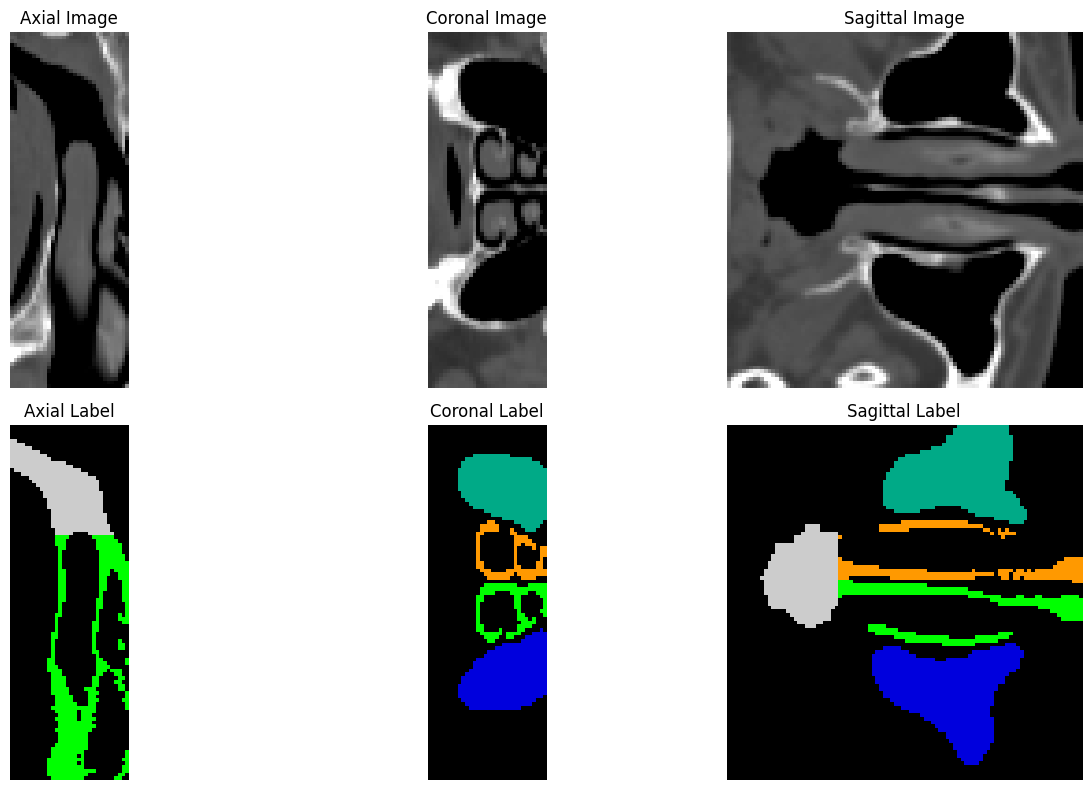

✅ Augmentation sanity-check saved.


In [11]:
# Visualization sanity check: one augmented training sample
batch = next(iter(train_loader))
img = batch["image"][0, 0].cpu().numpy()   # (D, H, W)
lbl = batch["label"][0, 0].cpu().numpy()

z = img.shape[0] // 2   # axial
y = img.shape[1] // 2   # coronal
x = img.shape[2] // 2   # sagittal

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
ax[0, 0].imshow(img[z],      cmap="gray");   ax[0, 0].set_title("Axial Image")
ax[1, 0].imshow(lbl[z],      cmap="nipy_spectral", vmin=0, vmax=CFG["num_classes"]-1)
ax[1, 0].set_title("Axial Label")

ax[0, 1].imshow(img[:, y, :], cmap="gray");  ax[0, 1].set_title("Coronal Image")
ax[1, 1].imshow(lbl[:, y, :], cmap="nipy_spectral", vmin=0, vmax=CFG["num_classes"]-1)
ax[1, 1].set_title("Coronal Label")

ax[0, 2].imshow(img[:, :, x], cmap="gray");  ax[0, 2].set_title("Sagittal Image")
ax[1, 2].imshow(lbl[:, :, x], cmap="nipy_spectral", vmin=0, vmax=CFG["num_classes"]-1)
ax[1, 2].set_title("Sagittal Label")

for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "augmentation_sanity_check.png"), dpi=120)
plt.show()
print("✅ Augmentation sanity-check saved.")

## Cell 11 — Model Definition & Complexity
SwinUNETR with gradient checkpointing (`use_checkpoint=True`) for memory-safe training on Kaggle GPUs.

In [12]:
def create_model():
    model = SwinUNETR(
        spatial_dims=3,
        in_channels=CFG["in_channels"],
        out_channels=CFG["num_classes"],
        feature_size=CFG["feature_size"],
        norm_name=CFG["norm_name"],
        use_checkpoint=CFG["use_checkpoint"],
        drop_rate=CFG["drop_rate"],
        attn_drop_rate=CFG["attn_drop_rate"],
        dropout_path_rate=CFG["dropout_path_rate"],
    ).to(CFG["device"])
    return model

model = create_model()

# ---- New Code!!----
#best_ckpt = "/kaggle/input/datasets/alaazaiter/bestmodel1/runs/swinunetr_nasalseg_run1/best_model.pth"

#model.load_state_dict(torch.load(best_ckpt, map_location=CFG["device"]))
#model.to(CFG["device"])

#print("Loaded best model from:", best_ckpt)
# --------------------

# ---- Model Complexity ----
try:
    with torch.no_grad():
        dummy = torch.randn(1, CFG["in_channels"], *CFG["roi_size"]).to(CFG["device"])
        flops = FlopCountAnalysis(model, dummy)
        macs  = flops.total()
        params = parameter_count(model)[""]
        print(f"\nModel Complexity:")
        print(f"  Parameters : {params / 1e6:.2f} M")
        print(f"  MACs       : {macs  / 1e9:.2f} G")
        with open(os.path.join(CFG["output_dir"], "model_complexity.json"), "w") as f:
            json.dump({"parameters": params, "macs": macs}, f, indent=2)
except Exception as e:
    params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters : {params / 1e6:.2f} M  (fvcore failed: {e})")


Model Complexity:
  Parameters : 62.19 M
  MACs       : 108.04 G


## Cell 11.1 — Recreate optimizer, scaler, scheduler normally
for fine tuning the best model

In [13]:
loss_fn   = DiceCELoss(to_onehot_y=True, softmax=True, weight=ce_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["learning_rate"],
    weight_decay=CFG["weight_decay"]
)

scaler = GradScaler('cuda', enabled=CFG["use_amp"])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    threshold_mode="abs",
)

## Cell 12 — Loss, Optimizer, Scheduler & Metrics

- **Loss:** `DiceCELoss` (combined Dice + Cross-Entropy) with `to_onehot_y=True` and `softmax=True`.
- **Optimizer:** `AdamW` (decoupled weight decay).
- **Scheduler:** `ReduceLROnPlateau` — halves LR if val loss stalls for 2 epochs.
- **Metrics:** Dice, IoU, Precision, Recall — all computed **without background** (`include_background=False`).

In [14]:

# ---- Metrics (exclude background for scoring) ----
dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
iou_metric = MeanIoU(include_background=False, reduction="mean_batch")
conf_matrix_metric = ConfusionMatrixMetric(
    include_background=False,
    metric_name=["precision", "sensitivity"],
    reduction="mean_batch",
    compute_sample=True
)

# Post-processing for metric computation
post_pred  = Compose([AsDiscrete(argmax=True, to_onehot=CFG["num_classes"])])
post_label = Compose([AsDiscrete(to_onehot=CFG["num_classes"])])

## Cell 13 — Training Epoch Function

In [15]:
def train_epoch(model, loader, loss_fn, optimizer, scaler, device, grad_clip=None):
    model.train()
    running_loss = 0.0
    for batch in tqdm(loader, desc="Train", leave=False):
        imgs = batch["image"].to(device)
        lbls = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast('cuda', enabled=CFG["use_amp"]):
            out  = model(imgs)
            loss = loss_fn(out, lbls)

        scaler.scale(loss).backward()
        if grad_clip:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    return running_loss / len(loader)

## Cell 14 — Validation Epoch Function

In [16]:
def validate_epoch(model, loader, loss_fn, device):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Val", leave=False):
            imgs = batch["image"].to(device)
            lbls = batch["label"].to(device)

            with autocast('cuda', enabled=CFG["use_amp"]):
                out = sliding_window_inference(
                    imgs,
                    roi_size=CFG["roi_size"],
                    sw_batch_size=CFG["sw_batch_size"],
                    predictor=model,
                    overlap=CFG["infer_overlap"],
                )
                loss = loss_fn(out, lbls)
                val_loss += loss.item()

            preds = [post_pred(i) for i in decollate_batch(out)]
            labs  = [post_label(i) for i in decollate_batch(lbls)]

            dice_metric(y_pred=preds, y=labs)
            iou_metric(y_pred=preds, y=labs)
            conf_matrix_metric(y_pred=preds, y=labs)

    val_loss /= len(loader)

    m_dice  = dice_metric.aggregate().cpu().numpy()
    m_iou   = iou_metric.aggregate().cpu().numpy()
    c_mats  = conf_matrix_metric.aggregate()

    m_precision = c_mats[0].cpu().numpy()
    m_recall    = c_mats[1].cpu().numpy()

    dice_metric.reset()
    iou_metric.reset()
    conf_matrix_metric.reset()

    return val_loss, m_dice, m_iou, m_precision, m_recall

## Cell 15 — Full Training & Validation Loop

Checkpoints are written directly into `/kaggle/working/runs/swinunetr_nasalseg_run1/`:
- `best_model.pth`
- `last_model.pth`
- `train_val_log.csv`

In [17]:
history       = []
best_val_dice = -1.0
last_ckpt     = os.path.join(CFG["output_dir"], "last_model.pth")
best_ckpt     = os.path.join(CFG["output_dir"], "best_model.pth")

early_stop_patience = 6
epochs_no_improve = 0
min_delta = 1e-4

print("Starting Training...")
start_time = time.time()

for epoch in range(CFG["max_epochs"]):
    print(f"\nEpoch {epoch+1}/{CFG['max_epochs']}")

    # ---- Train ----
    t_loss = train_epoch(model, train_loader, loss_fn,
                         optimizer, scaler, CFG["device"], CFG["grad_clip"])

    # ---- Validate ----
    v_loss, m_dice, m_iou, m_prec, m_rec = \
        validate_epoch(model, val_loader, loss_fn, CFG["device"])

    v_dice_mean = np.nanmean(m_dice)
    v_iou_mean  = np.nanmean(m_iou)

    # Step scheduler on validation loss
    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(v_dice_mean)
    new_lr = optimizer.param_groups[0]["lr"]
    
    print(
        f"  Scheduler best={scheduler.best:.6f} | "
        f"bad_epochs={scheduler.num_bad_epochs} | "
        f"LR {prev_lr:.2e} -> {new_lr:.2e}"
    )
    
    lr = new_lr
    
    print(f"  Train Loss : {t_loss:.4f} | Val Loss : {v_loss:.4f} | LR : {lr:.2e}")
    print(f"  Val Dice   : {v_dice_mean:.4f}  | Val IoU  : {v_iou_mean:.4f}")

    

    # ---- Log ----
    metrics = {
        "epoch": epoch + 1,
        "train_loss":     t_loss,
        "val_loss":       v_loss,
        "lr":             lr,
        "val_mean_dice":  v_dice_mean,
        "val_mean_iou":   v_iou_mean,
        "val_mean_prec":  np.nanmean(m_prec),
        "val_mean_recall": np.nanmean(m_rec),
    }
    # Per-class Dice
    for i in range(CFG["num_classes"] - 1):
        cname = CLASS_NAMES[i + 1]
        metrics[f"val_dice_{cname}"] = (
            m_dice[0, i] if m_dice.ndim > 1 else m_dice[i]
        )
    history.append(metrics)
    pd.DataFrame(history).to_csv(
        os.path.join(CFG["output_dir"], "train_val_log.csv"), index=False
    )


        # ---- Checkpoints + Early Stopping ----
    torch.save(model.state_dict(), last_ckpt)
    
    if v_dice_mean > best_val_dice + min_delta:
        best_val_dice = v_dice_mean
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_ckpt)
        print(f"  ⭐ New Best Dice: {best_val_dice:.4f}")
        print("  Saved best model to:", best_ckpt)
    else:
        epochs_no_improve += 1
        print(f"  No Dice improvement for {epochs_no_improve}/{early_stop_patience} epoch(s)")
    
    if epochs_no_improve >= early_stop_patience:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        break

elapsed = (time.time() - start_time) / 60
print(f"\n✅ Training completed in {elapsed:.1f} min.")

Starting Training...

Epoch 1/50


Train:   0%|          | 0/46 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


  Scheduler best=0.377991 | bad_epochs=0 | LR 1.00e-03 -> 1.00e-03
  Train Loss : 1.6548 | Val Loss : 1.1607 | LR : 1.00e-03
  Val Dice   : 0.3780  | Val IoU  : 0.2555
  ⭐ New Best Dice: 0.3780
  Saved best model to: /kaggle/working/runs/swinunetr_nasalseg_run1/best_model.pth

Epoch 2/50


...

Val:   0%|          | 0/19 [00:00<?, ?it/s]

  Scheduler best=0.864082 | bad_epochs=0 | LR 1.25e-04 -> 6.25e-05
  Train Loss : 0.7441 | Val Loss : 0.4383 | LR : 6.25e-05
  Val Dice   : 0.8630  | Val IoU  : 0.7871
  No Dice improvement for 3/6 epoch(s)

Epoch 50/50


Train:   0%|          | 0/46 [00:00<?, ?it/s]

Val:   0%|          | 0/19 [00:00<?, ?it/s]

  Scheduler best=0.864082 | bad_epochs=1 | LR 6.25e-05 -> 6.25e-05
  Train Loss : 0.7572 | Val Loss : 0.4311 | LR : 6.25e-05
  Val Dice   : 0.8625  | Val IoU  : 0.7859
  No Dice improvement for 4/6 epoch(s)

✅ Training completed in 56.6 min.


## Cell 16 — Post-Training Plots

Three plots:
1. **train_loss vs val_loss**
2. **val_mean_dice vs val_mean_iou**
3. **Learning rate schedule**

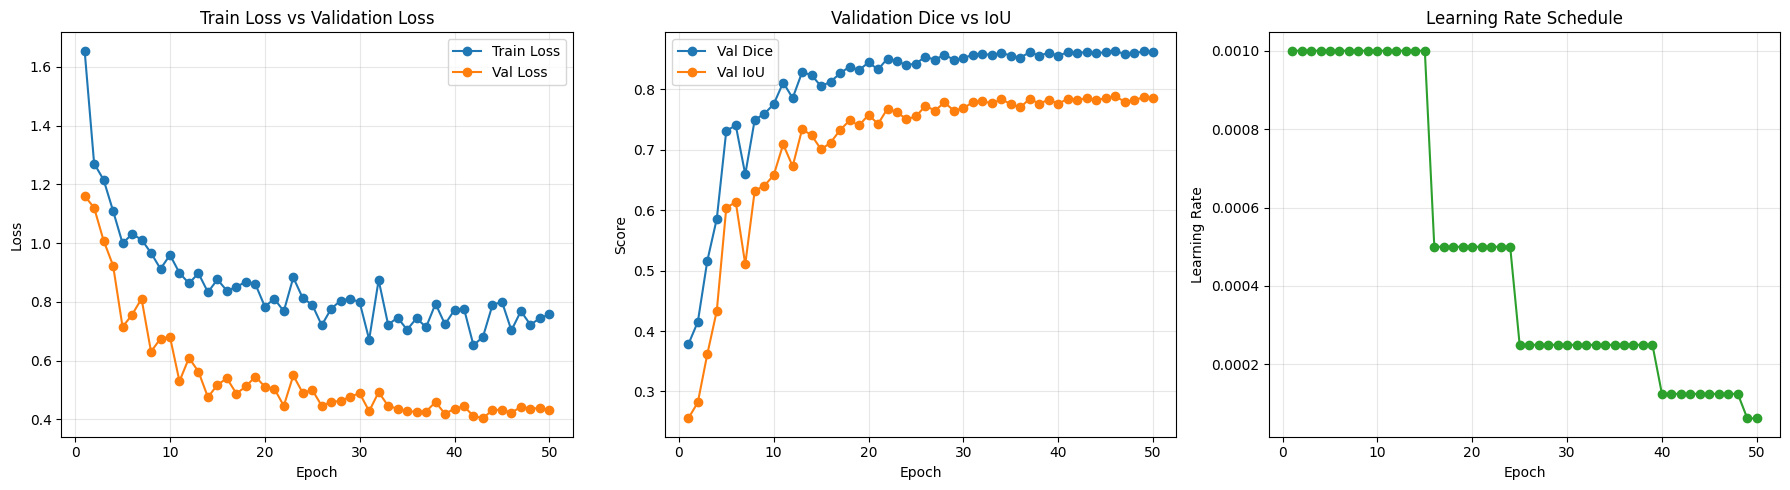

✅ Training curves saved.


In [18]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Loss
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", marker="o")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train Loss vs Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Dice & IoU
axes[1].plot(hist_df["epoch"], hist_df["val_mean_dice"], label="Val Dice", marker="o")
axes[1].plot(hist_df["epoch"], hist_df["val_mean_iou"],  label="Val IoU",  marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Dice vs IoU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Learning Rate
axes[2].plot(hist_df["epoch"], hist_df["lr"], marker="o", color="tab:green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "training_curves.png"), dpi=120)
plt.show()
print("✅ Training curves saved.")

## Cell 17 — Test-Set Evaluation
Load the best model and evaluate on the 26 held-out test cases.
Also measures inference speed per volume.

In [19]:
# ---- Test metrics (include all 6 classes, including background) ----
test_dice_metric = DiceMetric(include_background=True, reduction="mean_batch")
test_iou_metric = MeanIoU(include_background=True, reduction="mean_batch")
test_conf_matrix_metric = ConfusionMatrixMetric(
    include_background=True,
    metric_name=["precision", "sensitivity"],   # sensitivity = recall
    reduction="mean_batch",
    compute_sample=True
)

# class names
if "CLASS_NAMES" in globals() and len(CLASS_NAMES) == CFG["num_classes"]:
    TEST_CLASS_NAMES = CLASS_NAMES
else:
    TEST_CLASS_NAMES = [f"class_{i}" for i in range(CFG["num_classes"])]

In [20]:
best_ckpt = os.path.join(CFG["output_dir"], "best_model.pth")
print("Loading best model for test evaluation from:", best_ckpt)
assert os.path.exists(best_ckpt), f"Checkpoint not found: {best_ckpt}"

model.load_state_dict(torch.load(best_ckpt, map_location=CFG["device"], weights_only=True))
model.to(CFG["device"])
model.eval()

# reset test metrics
test_dice_metric.reset()
test_iou_metric.reset()
test_conf_matrix_metric.reset()

inf_times = []

with torch.no_grad():
    for idx, batch in enumerate(tqdm(test_loader, desc="Test")):
        imgs = batch["image"].to(CFG["device"])
        lbls = batch["label"].to(CFG["device"])

        t0 = time.time()
        with autocast('cuda', enabled=CFG["use_amp"]):
            out = sliding_window_inference(
                imgs,
                roi_size=CFG["roi_size"],
                sw_batch_size=CFG["sw_batch_size"],
                predictor=model,
                overlap=CFG["infer_overlap"],
            )
        inf_times.append(time.time() - t0)

        preds = [post_pred(i) for i in decollate_batch(out)]
        labs  = [post_label(i) for i in decollate_batch(lbls)]

        test_dice_metric(y_pred=preds, y=labs)
        test_iou_metric(y_pred=preds, y=labs)
        test_conf_matrix_metric(y_pred=preds, y=labs)

# ---- Aggregate metrics ----
t_dice  = test_dice_metric.aggregate().cpu().numpy()
t_iou   = test_iou_metric.aggregate().cpu().numpy()
t_cmats = test_conf_matrix_metric.aggregate()
t_prec  = t_cmats[0].cpu().numpy()
t_rec   = t_cmats[1].cpu().numpy()

avg_sec = np.mean(inf_times)

# make sure arrays are 1D
t_dice = np.array(t_dice).squeeze()
t_iou  = np.array(t_iou).squeeze()
t_prec = np.array(t_prec).squeeze()
t_rec  = np.array(t_rec).squeeze()

print("\n" + "=" * 55)
print("                 TEST RESULTS")
print("=" * 55)
print(f"Mean Dice      : {np.nanmean(t_dice):.4f}")
print(f"Mean IoU       : {np.nanmean(t_iou):.4f}")
print(f"Mean Precision : {np.nanmean(t_prec):.4f}")
print(f"Mean Recall    : {np.nanmean(t_rec):.4f}")
print("-" * 55)
print("Per-class metrics:")
for i, cname in enumerate(TEST_CLASS_NAMES):
    print(
        f"  {cname:<12} | "
        f"Dice: {t_dice[i]:.4f} | "
        f"IoU: {t_iou[i]:.4f} | "
        f"Precision: {t_prec[i]:.4f} | "
        f"Recall: {t_rec[i]:.4f}"
    )
print("-" * 55)
print(f"Inference Time : {avg_sec:.2f} s / volume")
print(f"Throughput     : {1.0 / avg_sec:.2f} volumes / s")

# ---- Save test metrics ----
test_summary = {
    "mean_dice": float(np.nanmean(t_dice)),
    "mean_iou": float(np.nanmean(t_iou)),
    "mean_precision": float(np.nanmean(t_prec)),
    "mean_recall": float(np.nanmean(t_rec)),
    "avg_sec_per_vol": float(avg_sec),
    "vols_per_sec": float(1.0 / avg_sec),
    "per_class": {}
}

for i, cname in enumerate(TEST_CLASS_NAMES):
    test_summary["per_class"][cname] = {
        "dice": float(t_dice[i]),
        "iou": float(t_iou[i]),
        "precision": float(t_prec[i]),
        "recall": float(t_rec[i]),
    }

test_path = os.path.join(CFG["output_dir"], "test_metrics.json")
with open(test_path, "w") as f:
    json.dump(test_summary, f, indent=2)

print(f"\n✅ Test metrics saved → {test_path}")

Loading best model for test evaluation from: /kaggle/working/runs/swinunetr_nasalseg_run1/best_model.pth


Test:   0%|          | 0/20 [00:00<?, ?it/s]


                 TEST RESULTS
Mean Dice      : 0.8743
Mean IoU       : 0.8102
Mean Precision : 0.8424
Mean Recall    : 0.9158
-------------------------------------------------------
Per-class metrics:
  0            | Dice: 0.9896 | IoU: 0.9796 | Precision: 0.9946 | Recall: 0.9846
  1            | Dice: 0.9107 | IoU: 0.8543 | Precision: 0.8797 | Recall: 0.9476
  2            | Dice: 0.8697 | IoU: 0.8104 | Precision: 0.8503 | Recall: 0.9053
  3            | Dice: 0.8009 | IoU: 0.7010 | Precision: 0.7440 | Recall: 0.8729
  4            | Dice: 0.8079 | IoU: 0.7138 | Precision: 0.7520 | Recall: 0.8772
  5            | Dice: 0.8669 | IoU: 0.8024 | Precision: 0.8338 | Recall: 0.9075
-------------------------------------------------------
Inference Time : 0.34 s / volume
Throughput     : 2.90 volumes / s

✅ Test metrics saved → /kaggle/working/runs/swinunetr_nasalseg_run1/test_metrics.json


## Cell 18 — Test Prediction Visualization
Axial / Coronal / Sagittal slices for a test case: Image | Ground Truth | Prediction.

Visualizing first test case...


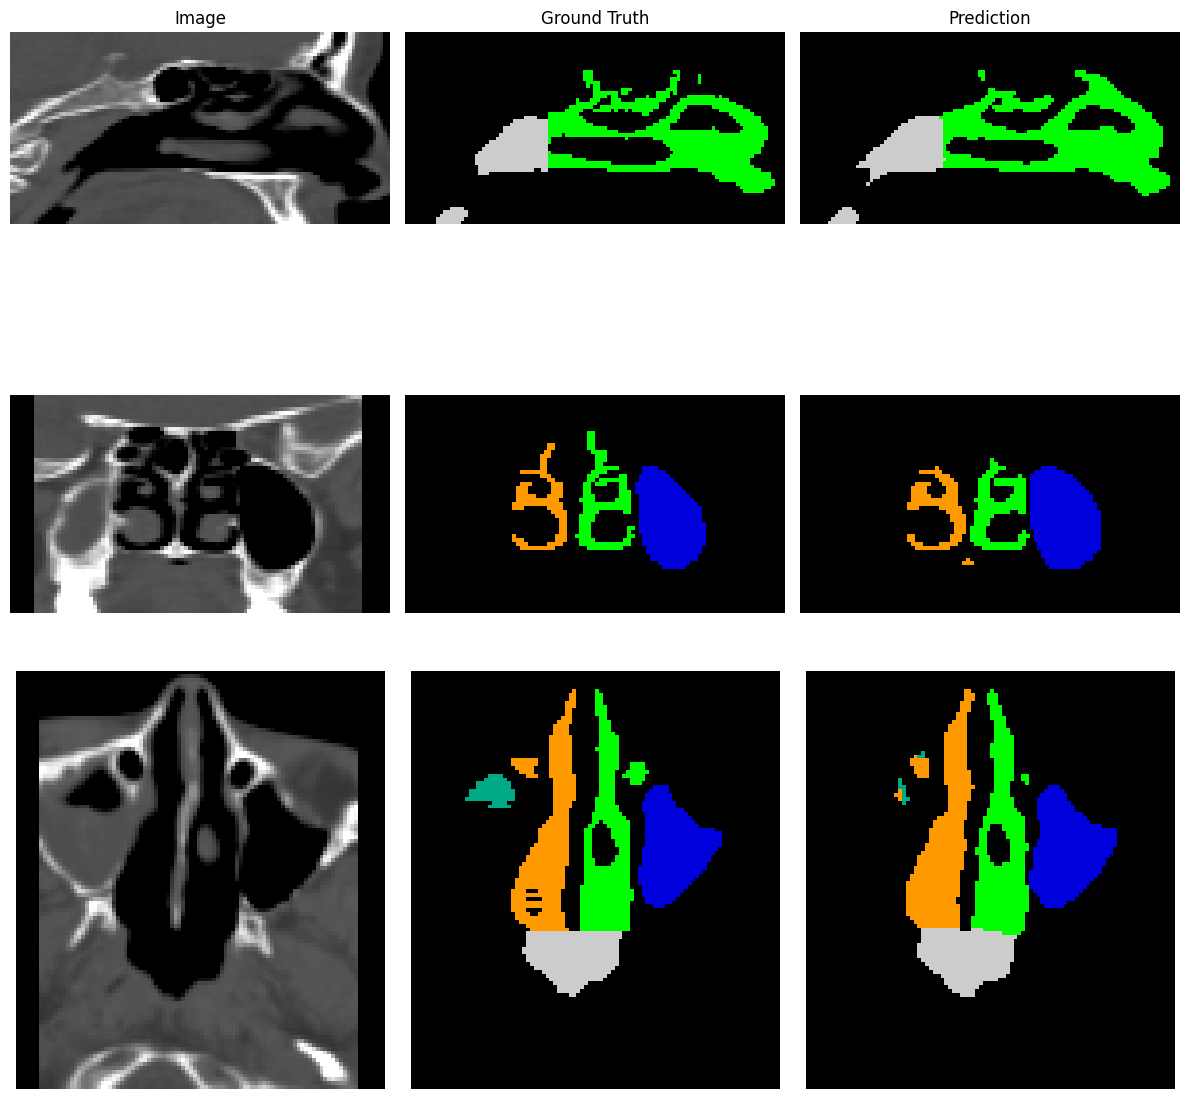

✅ Saved → /kaggle/working/runs/swinunetr_nasalseg_run1/test_pred_case_0.png


In [21]:
def visualize_case(model, loader, device, idx=0):
    """Display axial/coronal/sagittal views for one test case."""
    model.eval()
    subset = [d for i, d in enumerate(loader.dataset) if i == idx]
    if not subset:
        return
    batch = list_data_collate([subset[0]])

    img = batch["image"].to(device)
    lbl = batch["label"].cpu().numpy()[0, 0]    # (C, D, H, W) or (1, D, H, W)

    with torch.no_grad():
        with autocast('cuda', enabled=CFG["use_amp"]):
            pred = sliding_window_inference(
                img,
                roi_size=CFG["roi_size"],
                sw_batch_size=CFG["sw_batch_size"],
                predictor=model,
                overlap=CFG["infer_overlap"],
            )
        pred = torch.argmax(pred, dim=1).cpu().numpy()[0]

    img_np = img.cpu().numpy()[0, 0]

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    slices = [s // 2 for s in img_np.shape]
    titles = ["Image", "Ground Truth", "Prediction"]

    for row, (axis, sl) in enumerate(zip([0, 1, 2], slices)):
        p_img = np.take(img_np, sl, axis=axis)
        p_lbl = np.take(lbl,    sl, axis=axis)
        p_prd = np.take(pred,   sl, axis=axis)
        axes[row, 0].imshow(p_img.T, cmap="gray",          origin="lower")
        axes[row, 1].imshow(p_lbl.T, cmap="nipy_spectral", origin="lower",
                            vmin=0, vmax=CFG["num_classes"] - 1)
        axes[row, 2].imshow(p_prd.T, cmap="nipy_spectral", origin="lower",
                            vmin=0, vmax=CFG["num_classes"] - 1)
        axes[row, 0].set_ylabel(["Axial", "Coronal", "Sagittal"][row])
        if row == 0:
            for c, t in enumerate(titles):
                axes[0, c].set_title(t)
    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    out_path = os.path.join(CFG["output_dir"], f"test_pred_case_{idx}.png")
    plt.savefig(out_path, dpi=120)
    plt.show()
    print(f"✅ Saved → {out_path}")

print("Visualizing first test case...")
visualize_case(model, test_loader, CFG["device"], idx=0)

## Cell 19 — Summary of Output Files
List everything written to `/kaggle/working/runs/swinunetr_nasalseg_run1/`.

In [23]:
print("\nOutput directory contents:")
print("=" * 60)
for f in sorted(os.listdir(CFG["output_dir"])):
    fpath = os.path.join(CFG["output_dir"], f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f:40s}  {size_kb:>10.1f} KB")
print("=" * 60)
print("\n✅ All outputs are under /kaggle/working/ and will be preserved.")


Output directory contents:
  augmentation_sanity_check.png                   54.4 KB
  best_model.pth                              250337.2 KB
  last_model.pth                              250337.2 KB
  model_complexity.json                            0.1 KB
  split_summary.json                               1.6 KB
  test_metrics.json                                1.2 KB
  test_pred_case_0.png                            61.3 KB
  train_val_log.csv                                7.1 KB
  training_curves.png                            115.6 KB

✅ All outputs are under /kaggle/working/ and will be preserved.
